## 1. Setup and import

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# graph configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

custom_palette = ["#3A86C8", "#FF6B6B", "#4E9F3D", "#FAB733", "#7A1FA2", "#8D99AE"]
sns.set_palette(sns.color_palette(custom_palette))

# Loading STATA dataset
file_path = "Database_STATA_EN/Database_ENG.dta"
df = pd.read_stata(file_path)
print(f"Dimension: {df.shape[0]} rows and {df.shape[1]} cols.")

Dimension: 4862 rows and 219 cols.


## 2. Data Cleaning and Variable Mapping

In [35]:
df_clean = df.copy()

# replacing missing codes with NaN
missing_codes = [-99, -98, -97, -999, -99.0, -98.0, -97.0, -999.0]
for code in missing_codes:
    df_clean = df_clean.replace(code, np.nan)

# gender mapping
df_clean['gender'] = df['qd1'].map({1: 'Male', 0: 'Female'})

# age mapping
df_clean['age'] = df_clean['qd7']
df_clean['age_class'] = pd.cut(df_clean['age'], 
                                bins=[0, 29, 44, 59, 74, 100], 
                                labels=['Under 30', '30-44', '45-59', '60-74', '75+'])

# macro-region mapping (qd2)
macro_region_labels = {1: 'North-West', 2: 'North-East', 3: 'Center', 4: 'South', 5: 'Islands'}
df_clean['macro_region'] = df_clean['qd2'].map(macro_region_labels)

# residence place mapping (qd3)
urban_labels = {1: 'Rural (<3k inh.)', 2: 'Small town (3k-15k)', 3: 'Medium town (15k-100k)', 
                4: 'Large city (100k-1M)', 5: 'Metropolis (>1M)'}
df_clean['urbanization'] = df_clean['qd3'].map(urban_labels)

# education level mapping (qd9)
edu_labels = {
    1: 'Post-graduate', 2: 'Master\'s degree', 3: 'Bachelor\'s degree',
    4: 'Unfinished university', 5: 'High school diploma', 6: 'Unfinished high school',
    7: 'Middle school diploma', 8: 'Unfinished middle school', 9: 'Elementary school diploma', 
    10: 'No degree'
}
df_clean['education_detail'] = df_clean['qd9'].map(edu_labels)
df_clean['education'] = df_clean['qd9'].map({
    1: 'University or higher', 2: 'University or higher', 3: 'University or higher',
    4: 'High school diploma', 5: 'High school diploma', 
    6: 'Up to middle school', 7: 'Up to middle school', 8: 'Up to middle school',
    9: 'Up to middle school', 10: 'Up to middle school'
})

# job mapping (qd10)
work_labels = {
    1: 'Self-employed', 2: 'Employee', 3: 'Apprentice', 4: 'Homemaker', 
    5: 'Unemployed', 6: 'Retired', 7: 'Disabled', 8: 'Inactive', 
    9: 'Student', 10: 'Other'
}
df_clean['job'] = df_clean['qd10'].map(work_labels)

# economic mapping (qd13)
income_labels = {1: 'Up to €1750', 2: '€1751 - €2900', 3: 'Over €2900'}
df_clean['income'] = df_clean['qd13'].map(income_labels)

## 3. Demographic and Socio-Economic Profile of Respondents

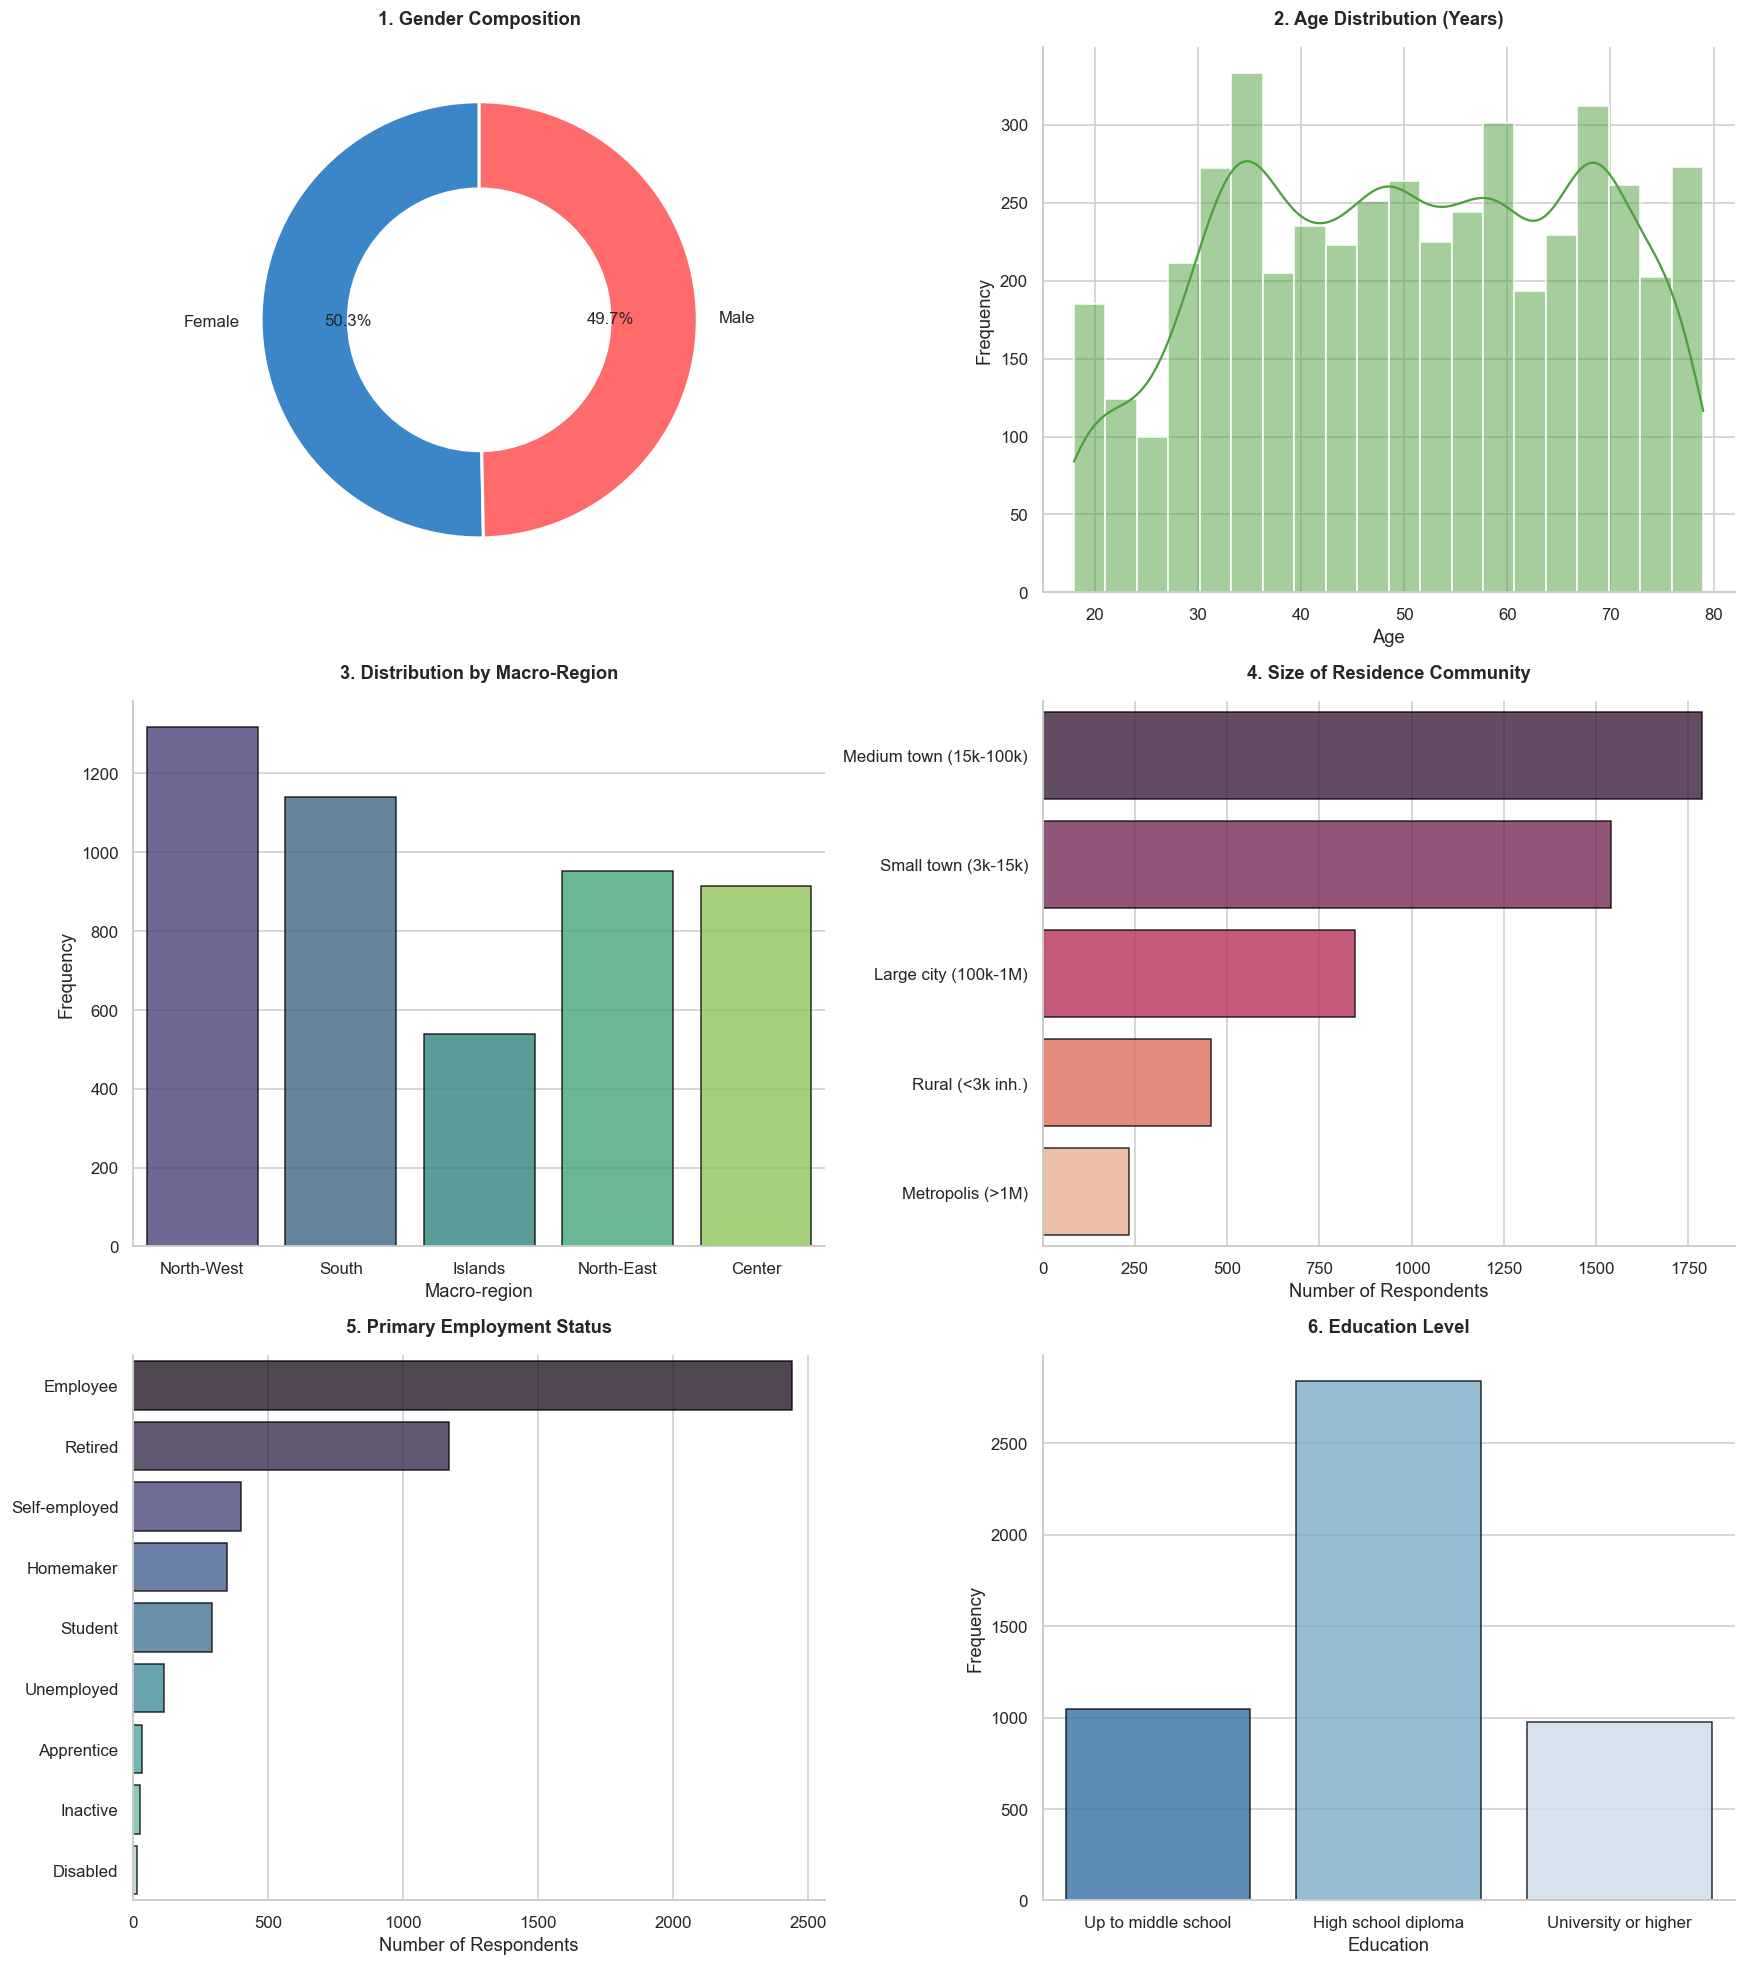

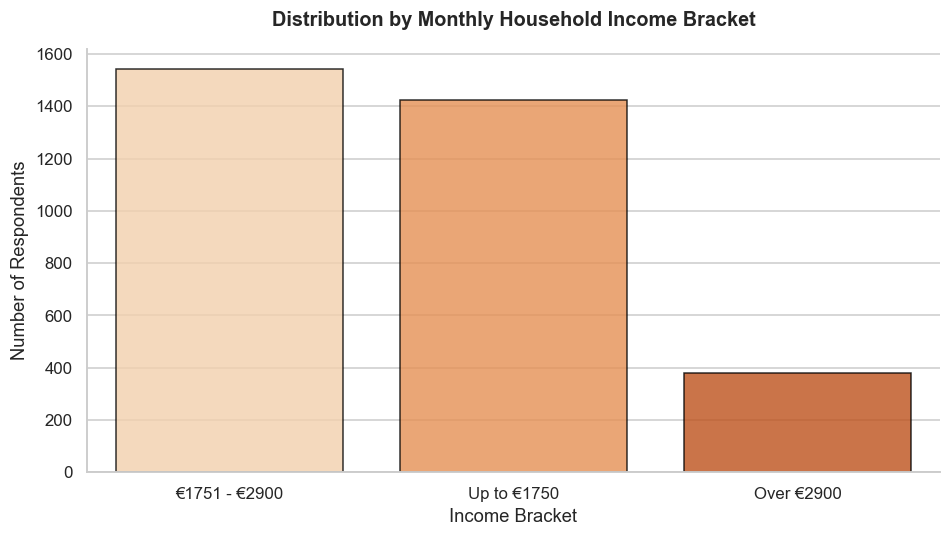

In [36]:
# Demographic charts panel configuration
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Gender Distribution
gender_data = df_clean['gender'].value_counts(dropna=True)
axes[0, 0].pie(gender_data, labels=gender_data.index, autopct='%1.1f%%', startangle=90,
            colors=["#3A86C8", "#FF6B6B"], wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[0, 0].set_title("1. Gender Composition")

# 2. Age Distribution
sns.histplot(data=df_clean, x='age', kde=True, color="#4E9F3D", ax=axes[0, 1], bins=20)
axes[0, 1].set_title("2. Age Distribution (Years)")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Frequency")

# 3. Macro-Region Distribution
sns.countplot(data=df_clean, x='macro_region', palette="viridis", ax=axes[1, 0], edgecolor="black", alpha=0.8)
axes[1, 0].set_title("3. Distribution by Macro-Region")
axes[1, 0].set_xlabel("Macro-region")
axes[1, 0].set_ylabel("Frequency")

# 4. Urbanization Distribution
sns.countplot(data=df_clean, y='urbanization', palette="rocket", ax=axes[1, 1], edgecolor="black", alpha=0.8)
axes[1, 1].set_title("4. Size of Residence Community")
axes[1, 1].set_xlabel("Number of Respondents")
axes[1, 1].set_ylabel("")

# 5. Job Status Distribution
sns.countplot(data=df_clean, y='job', palette="mako", ax=axes[2, 0], edgecolor="black", alpha=0.8,
              order=df_clean['job'].value_counts().index)
axes[2, 0].set_title("5. Primary Employment Status")
axes[2, 0].set_xlabel("Number of Respondents")
axes[2, 0].set_ylabel("")

# 6. Education Distribution
sns.countplot(data=df_clean, x='education', palette="Blues_r", ax=axes[2, 1], edgecolor="black", alpha=0.8,
              order=['Up to middle school', 'High school diploma', 'University or higher'])
axes[2, 1].set_title("6. Education Level")
axes[2, 1].set_xlabel("Education")
axes[2, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 7. Separate Monthly Income Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean.dropna(subset=['income']), x='income', palette="Oranges", edgecolor="black", alpha=0.8)
plt.title("Distribution by Monthly Household Income Bracket", fontsize=13)
plt.xlabel("Income Bracket")
plt.ylabel("Number of Respondents")
plt.show()

## 4. Household Financial Planning and Management (`qf`)

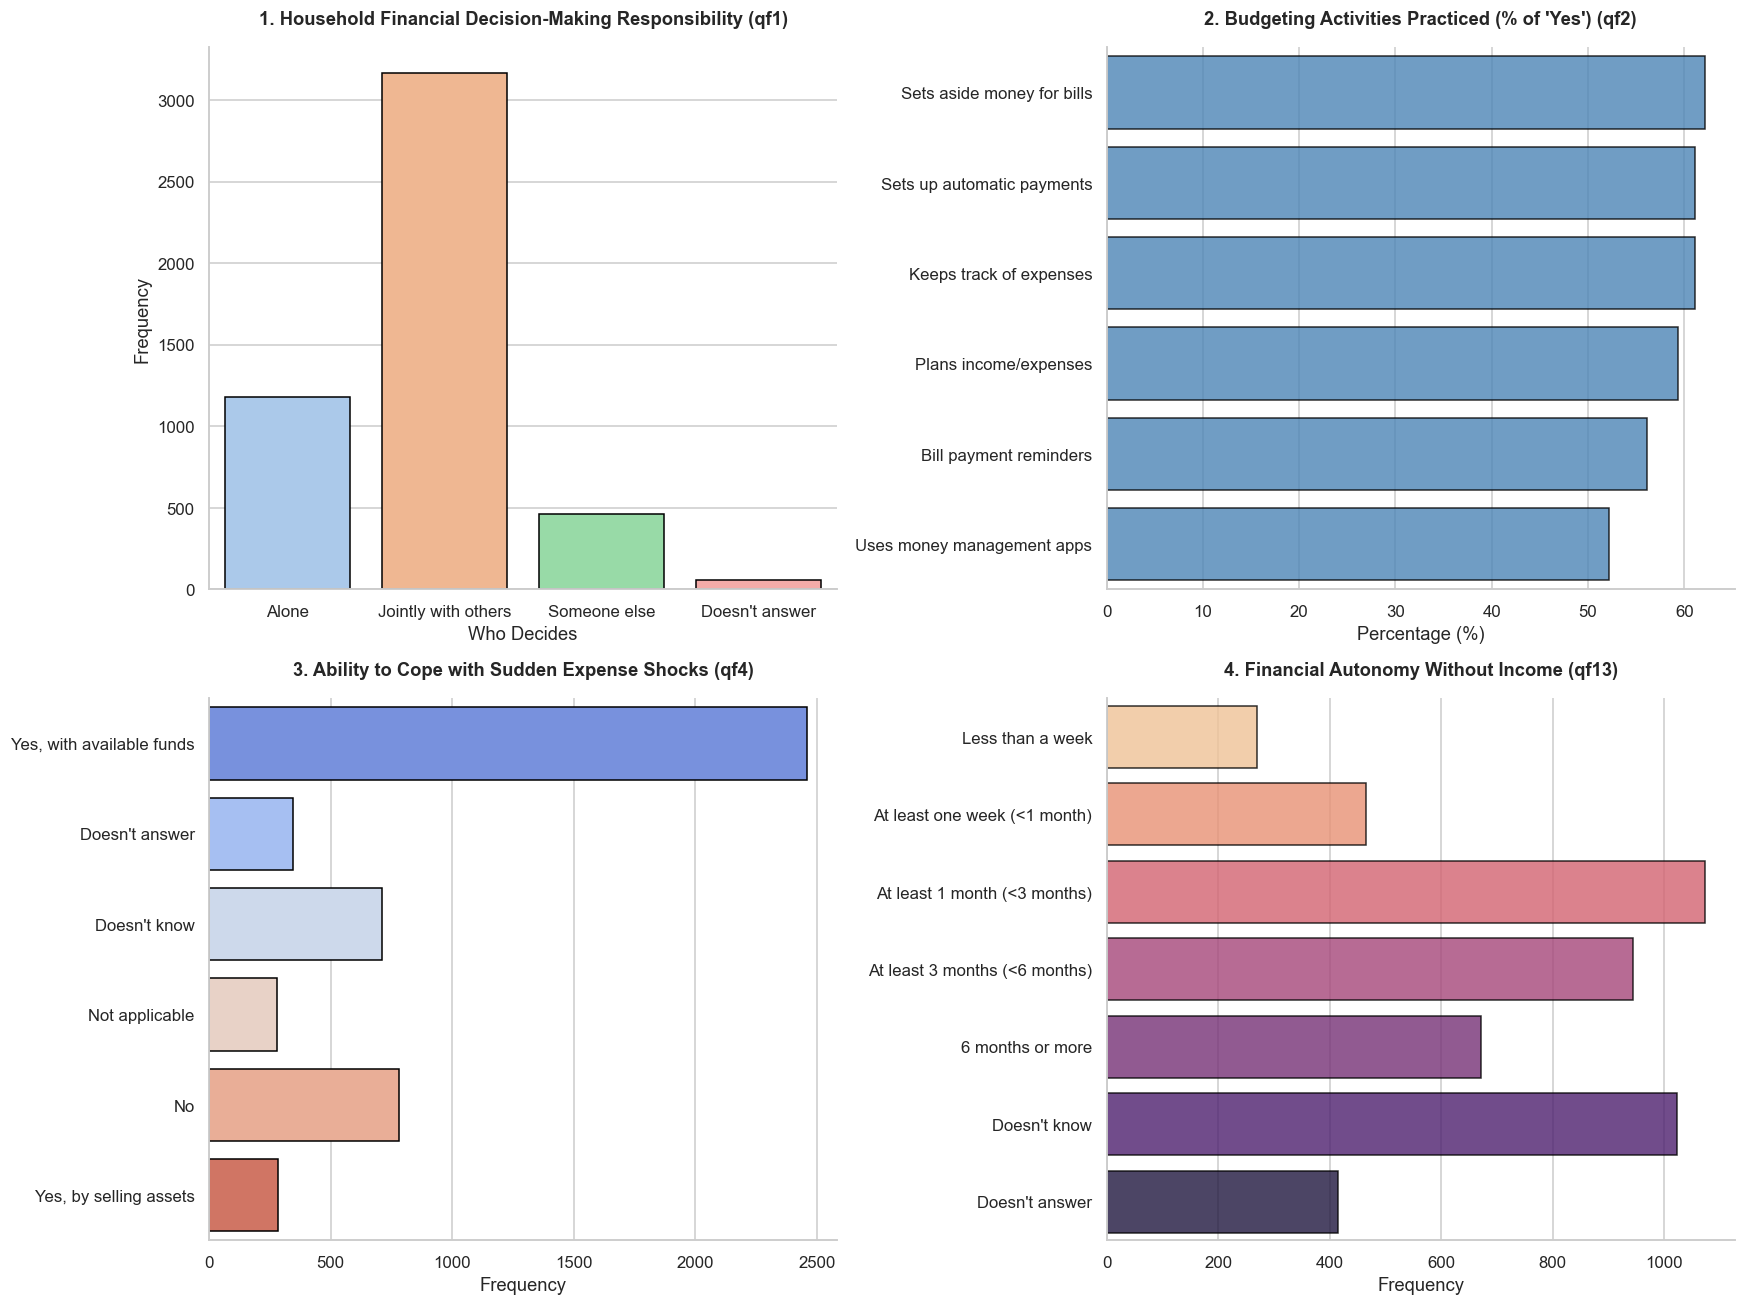

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Who makes financial decisions in the household? (qf1)
df_clean['money_decisions'] = df['qf1'].map({
    1: 'Alone',
    2: 'Jointly with others',
    3: 'Someone else',
    -97: "Doesn't know",
    -99: "Doesn't answer"
})
sns.countplot(data=df_clean, x='money_decisions', palette="pastel", ax=axes[0, 0], edgecolor="black")
axes[0, 0].set_title("1. Household Financial Decision-Making Responsibility (qf1)")
axes[0, 0].set_xlabel("Who Decides")
axes[0, 0].set_ylabel("Frequency")

# 2. Active budgeting behaviors and tracking expenses (qf2)
qf2_map = {
    'qf2_1': 'Plans income/expenses',
    'qf2_2': 'Keeps track of expenses',
    'qf2_3': 'Sets aside money for bills',
    'qf2_4': 'Bill payment reminders',
    'qf2_5': 'Uses money management apps',
    'qf2_6': 'Sets up automatic payments'
}

qf2_df = df[list(qf2_map.keys())].apply(lambda col: (col == 1).mean() * 100).reset_index()
qf2_df.columns = ['Variable', 'Percentage_Yes']
qf2_df['Behavior'] = qf2_df['Variable'].map(qf2_map)
qf2_df = qf2_df.sort_values(by='Percentage_Yes', ascending=False)

sns.barplot(data=qf2_df, x='Percentage_Yes', y='Behavior', color="#3A86C8", ax=axes[0, 1], edgecolor="black", alpha=0.8)
axes[0, 1].set_title("2. Budgeting Activities Practiced (% of 'Yes') (qf2)")
axes[0, 1].set_xlabel("Percentage (%)")
axes[0, 1].set_ylabel("")

# 3. Ability to face a sudden expense equal to monthly income without borrowing (qf4)
df_clean['expense_shock'] = df['qf4'].map({
    1: 'Yes, with available funds',
    2: 'Yes, by selling assets',
    0: 'No',
    -97: "Doesn't know",
    -98: 'Not applicable',
    -99: "Doesn't answer"
})
sns.countplot(data=df_clean, y='expense_shock', palette="coolwarm", ax=axes[1, 0], edgecolor="black")
axes[1, 0].set_title("3. Ability to Cope with Sudden Expense Shocks (qf4)")
axes[1, 0].set_xlabel("Frequency")
axes[1, 0].set_ylabel("")

# 4. Expense coverage time in case of job loss (qf13)
df_clean['job_loss_coverage'] = df['qf13'].map({
    1: 'Less than a week',
    2: 'At least one week (<1 month)',
    3: 'At least 1 month (<3 months)',
    4: 'At least 3 months (<6 months)',
    5: '6 months or more',
    -97: "Doesn't know",
    -99: "Doesn't answer"
})
sns.countplot(data=df_clean, y='job_loss_coverage', palette="magma_r", ax=axes[1, 1], edgecolor="black", alpha=0.8,
              order=['Less than a week', 'At least one week (<1 month)', 'At least 1 month (<3 months)',
                     'At least 3 months (<6 months)', '6 months or more', "Doesn't know", "Doesn't answer"])
axes[1, 1].set_title("4. Financial Autonomy Without Income (qf13)")
axes[1, 1].set_xlabel("Frequency")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Choice and Use of Financial Products (`qp`)

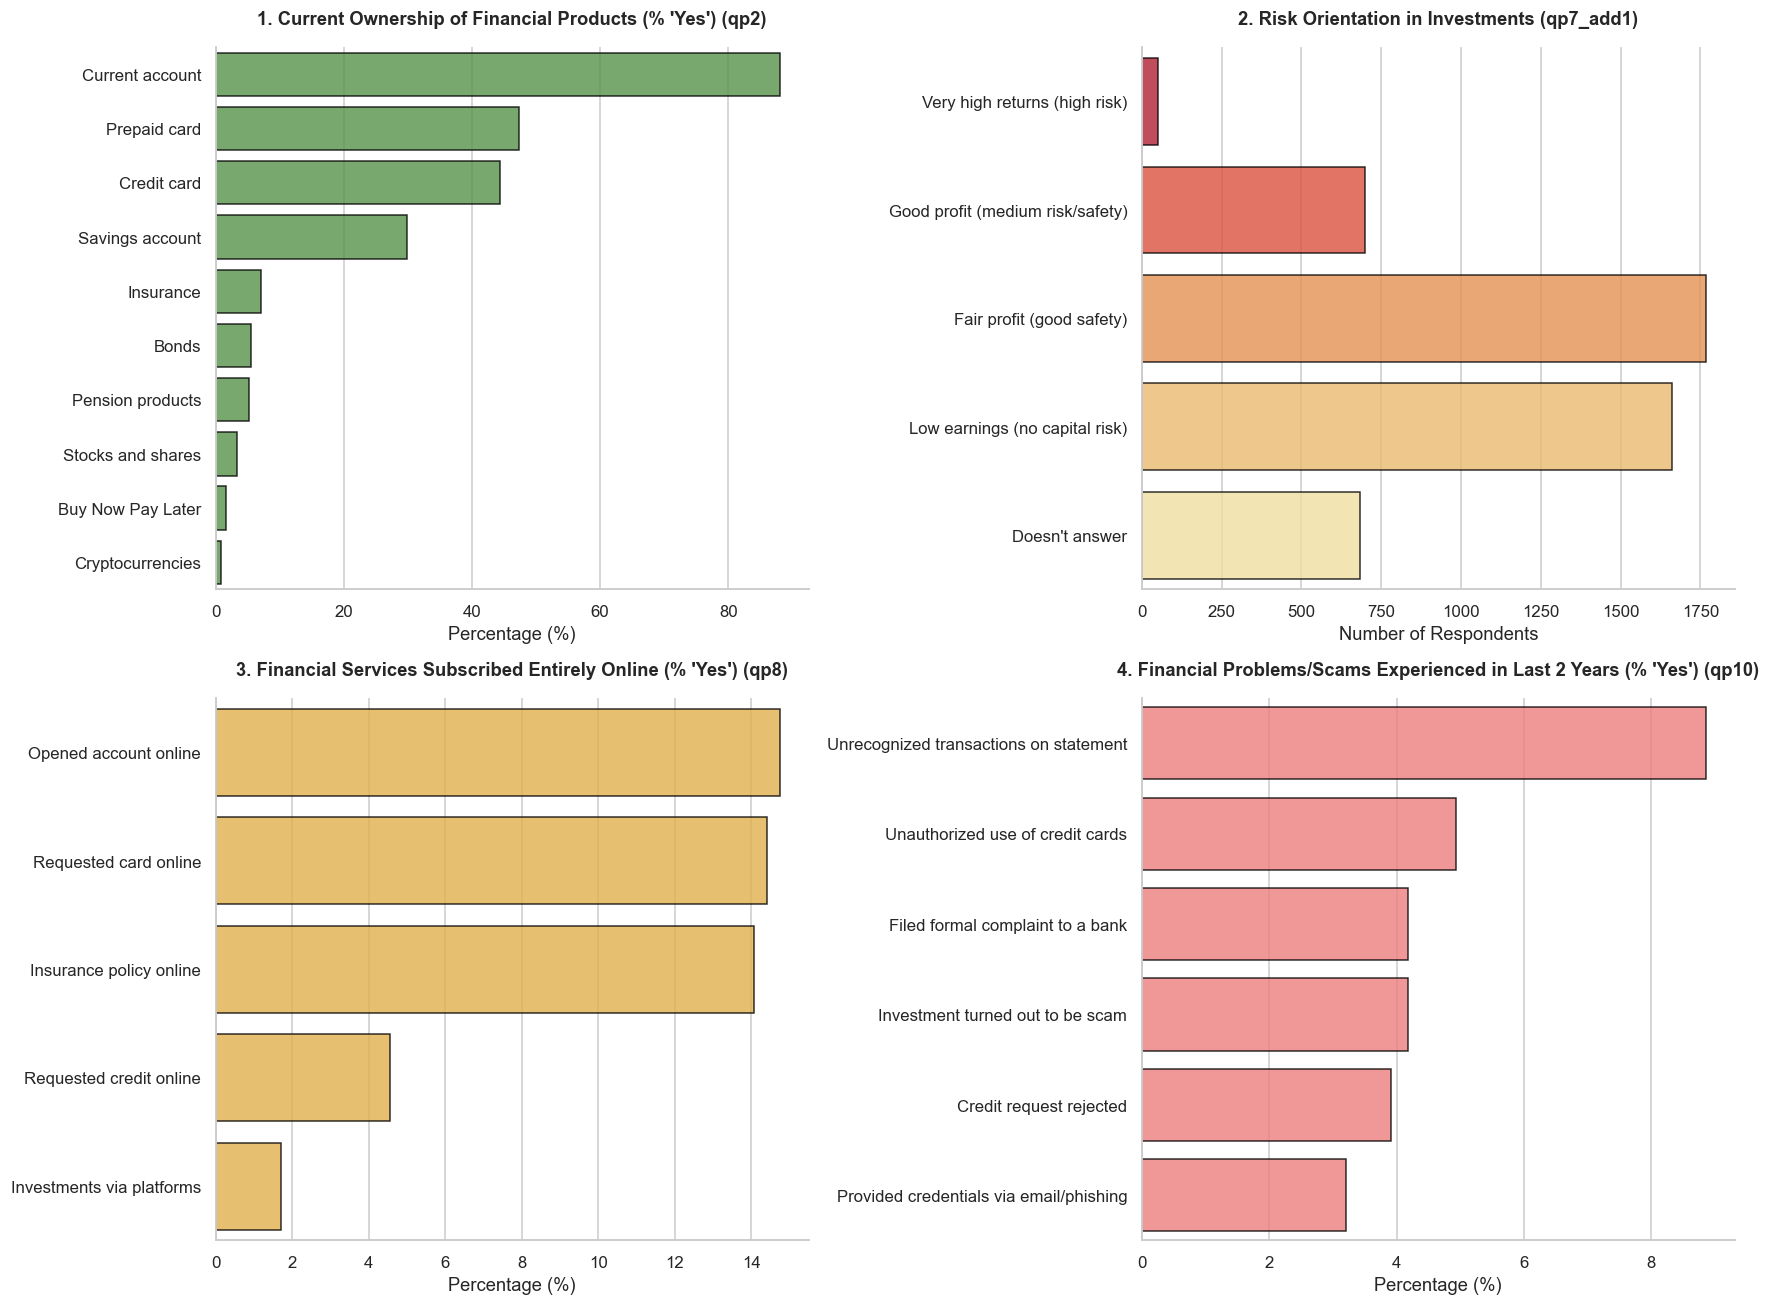

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Current Ownership of Financial Products (qp2)
qp2_map = {
    'qp2_8': 'Current account',
    'qp2_9': 'Savings account',
    'qp2_15': 'Prepaid card',
    'qp2_7': 'Credit card',
    'qp2_1': 'Pension products',
    'qp2_11': 'Insurance',
    'qp2_12': 'Stocks and shares',
    'qp2_13': 'Bonds',
    'qp2_16': 'Cryptocurrencies',
    'qp2_add_3': 'Buy Now Pay Later'
}

qp2_df = df[list(qp2_map.keys())].apply(lambda col: (col == 1).mean() * 100).reset_index()
qp2_df.columns = ['Variable', 'Percentage_Yes']
qp2_df['Product'] = qp2_df['Variable'].map(qp2_map)
qp2_df = qp2_df.sort_values(by='Percentage_Yes', ascending=False)

sns.barplot(data=qp2_df, x='Percentage_Yes', y='Product', color="#4E9F3D", ax=axes[0, 0], edgecolor="black", alpha=0.8)
axes[0, 0].set_title("1. Current Ownership of Financial Products (% 'Yes') (qp2)")
axes[0, 0].set_xlabel("Percentage (%)")
axes[0, 0].set_ylabel("")

# 2. Risk Orientation of investors (qp7_add1)
df_clean['risk_propensity'] = df['qp7_add1'].map({
    1: 'Very high returns (high risk)',
    2: 'Good profit (medium risk/safety)',
    3: 'Fair profit (good safety)',
    4: 'Low earnings (no capital risk)',
    -99: "Doesn't answer"
})
sns.countplot(data=df_clean, y='risk_propensity', palette="YlOrRd_r", ax=axes[0, 1], edgecolor="black", alpha=0.8,
              order=['Very high returns (high risk)', 'Good profit (medium risk/safety)',
                     'Fair profit (good safety)', 'Low earnings (no capital risk)', "Doesn't answer"])
axes[0, 1].set_title("2. Risk Orientation in Investments (qp7_add1)")
axes[0, 1].set_xlabel("Number of Respondents")
axes[0, 1].set_ylabel("")

# 3. Financial activities opened/requested entirely online (qp8)
qp8_map = {
    'qp8_1': 'Opened account online',
    'qp8_2': 'Requested card online',
    'qp8_3': 'Insurance policy online',
    'qp8_4': 'Requested credit online',
    'qp8_5': 'Investments via platforms'
}
qp8_df = df[list(qp8_map.keys())].apply(lambda col: (col == 1).mean() * 100).reset_index()
qp8_df.columns = ['Variable', 'Percentage_Yes']
qp8_df['Online_Activity'] = qp8_df['Variable'].map(qp8_map)
qp8_df = qp8_df.sort_values(by='Percentage_Yes', ascending=False)

sns.barplot(data=qp8_df, x='Percentage_Yes', y='Online_Activity', color="#FAB733", ax=axes[1, 0], edgecolor="black", alpha=0.8)
axes[1, 0].set_title("3. Financial Services Subscribed Entirely Online (% 'Yes') (qp8)")
axes[1, 0].set_xlabel("Percentage (%)")
axes[1, 0].set_ylabel("")

# 4. Negative experiences and fraud suffered (qp10)
qp10_map = {
    'qp10_1': 'Investment turned out to be scam',
    'qp10_2': 'Provided credentials via email/phishing',
    'qp10_3': 'Unauthorized use of credit cards',
    'qp10_4': 'Unrecognized transactions on statement',
    'qp10_5': 'Filed formal complaint to a bank',
    'qp10_8': 'Credit request rejected'
}
qp10_df = df[list(qp10_map.keys())].apply(lambda col: (col == 1).mean() * 100).reset_index()
qp10_df.columns = ['Variable', 'Percentage_Yes']
qp10_df['Problem'] = qp10_df['Variable'].map(qp10_map)
qp10_df = qp10_df.sort_values(by='Percentage_Yes', ascending=False)

sns.barplot(data=qp10_df, x='Percentage_Yes', y='Problem', color="#FF6B6B", ax=axes[1, 1], edgecolor="black", alpha=0.8)
axes[1, 1].set_title("4. Financial Problems/Scams Experienced in Last 2 Years (% 'Yes') (qp10)")
axes[1, 1].set_xlabel("Percentage (%)")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Classical and Digital Financial Knowledge (`qk`)

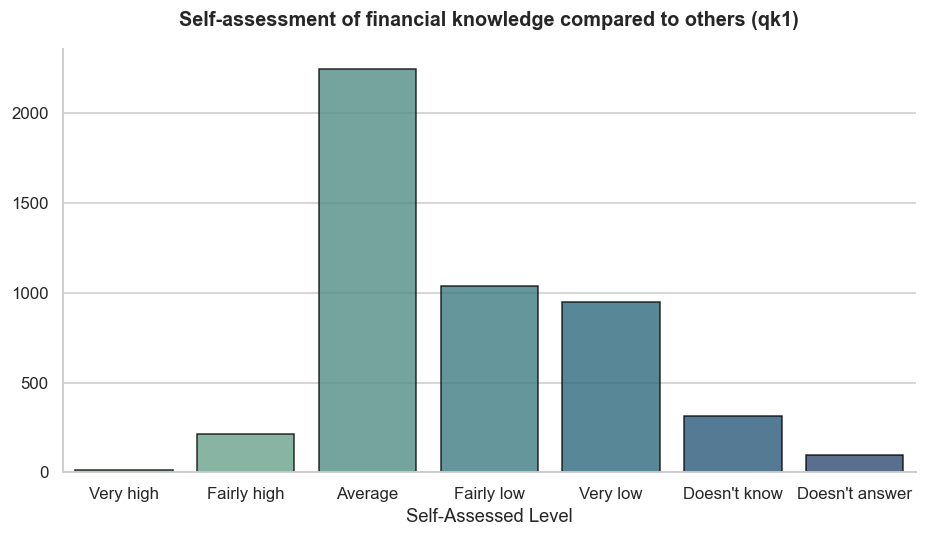

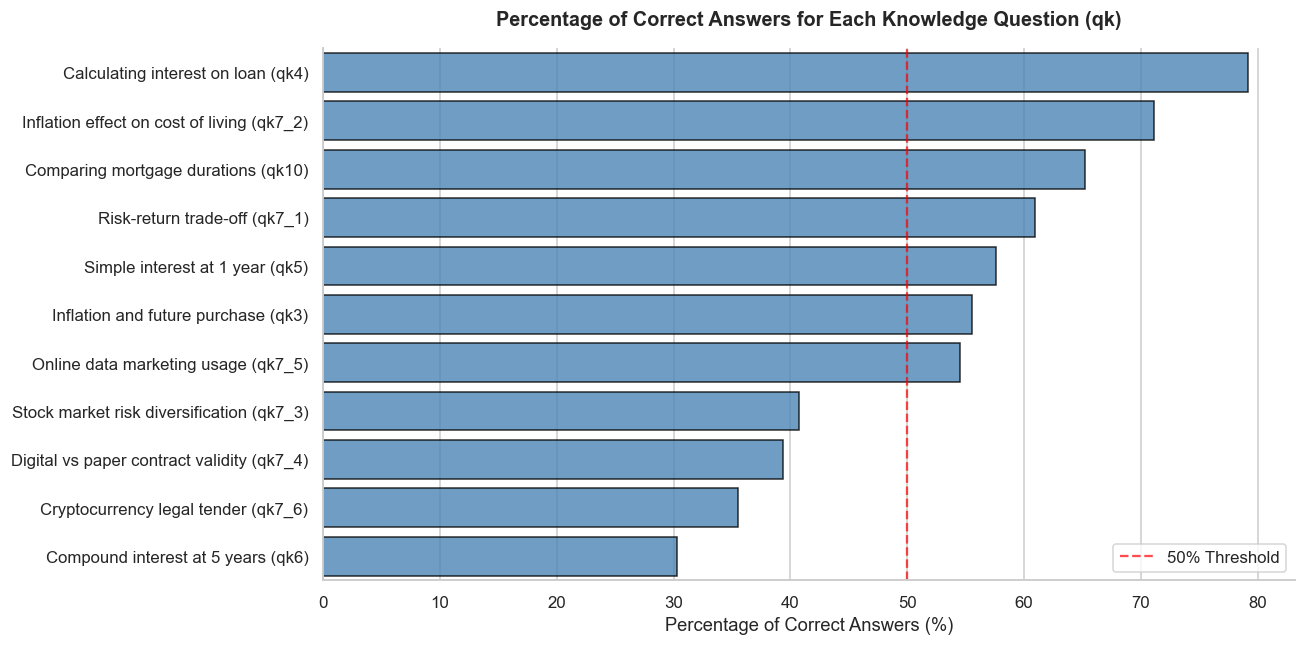

In [39]:
# 1. Subjective Self-Assessment of Financial Knowledge (qk1)
df_clean['self_assessed_knowledge'] = df['qk1'].map({
    1: 'Very high',
    2: 'Fairly high',
    3: 'Average',
    4: 'Fairly low',
    5: 'Very low',
    -97: "Doesn't know",
    -99: "Doesn't answer"
})

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='self_assessed_knowledge', palette="crest", edgecolor="black", alpha=0.8,
              order=['Very high', 'Fairly high', 'Average', 'Fairly low', 'Very low', "Doesn't know", "Doesn't answer"])
plt.title("Self-assessment of financial knowledge compared to others (qk1)", fontsize=13)
plt.xlabel("Self-Assessed Level")
plt.ylabel("")
plt.show()

# 2. Correct Answers Rate on the 11 Financial Knowledge Questions
risposte_corrette = {
    'qk3': 3, 'qk4': 0, 'qk5': 102, 'qk6': 1,
    'qk7_1': 1, 'qk7_2': 1, 'qk7_3': 1, 'qk7_4': 0, 'qk7_5': 1, 'qk7_6': 0,
    'qk10': 1
}

correct_scores = {}
for q, correct in risposte_corrette.items():
    correct_scores[q] = (df[q] == correct).mean() * 100

qk_descriptions = {
    'qk3': 'Inflation and future purchase (qk3)',
    'qk4': 'Calculating interest on loan (qk4)',
    'qk5': 'Simple interest at 1 year (qk5)',
    'qk6': 'Compound interest at 5 years (qk6)',
    'qk7_1': 'Risk-return trade-off (qk7_1)',
    'qk7_2': 'Inflation effect on cost of living (qk7_2)',
    'qk7_3': 'Stock market risk diversification (qk7_3)',
    'qk7_4': 'Digital vs paper contract validity (qk7_4)',
    'qk7_5': 'Online data marketing usage (qk7_5)',
    'qk7_6': 'Cryptocurrency legal tender (qk7_6)',
    'qk10': 'Comparing mortgage durations (qk10)'
}

qk_df = pd.DataFrame(list(correct_scores.items()), columns=['Variable', 'Correct'])
qk_df['Question'] = qk_df['Variable'].map(qk_descriptions)
qk_df = qk_df.sort_values(by='Correct', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=qk_df, x='Correct', y='Question', color="#3A86C8", edgecolor="black", alpha=0.8)
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% Threshold')
plt.title("Percentage of Correct Answers for Each Knowledge Question (qk)", fontsize=13)
plt.xlabel("Percentage of Correct Answers (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

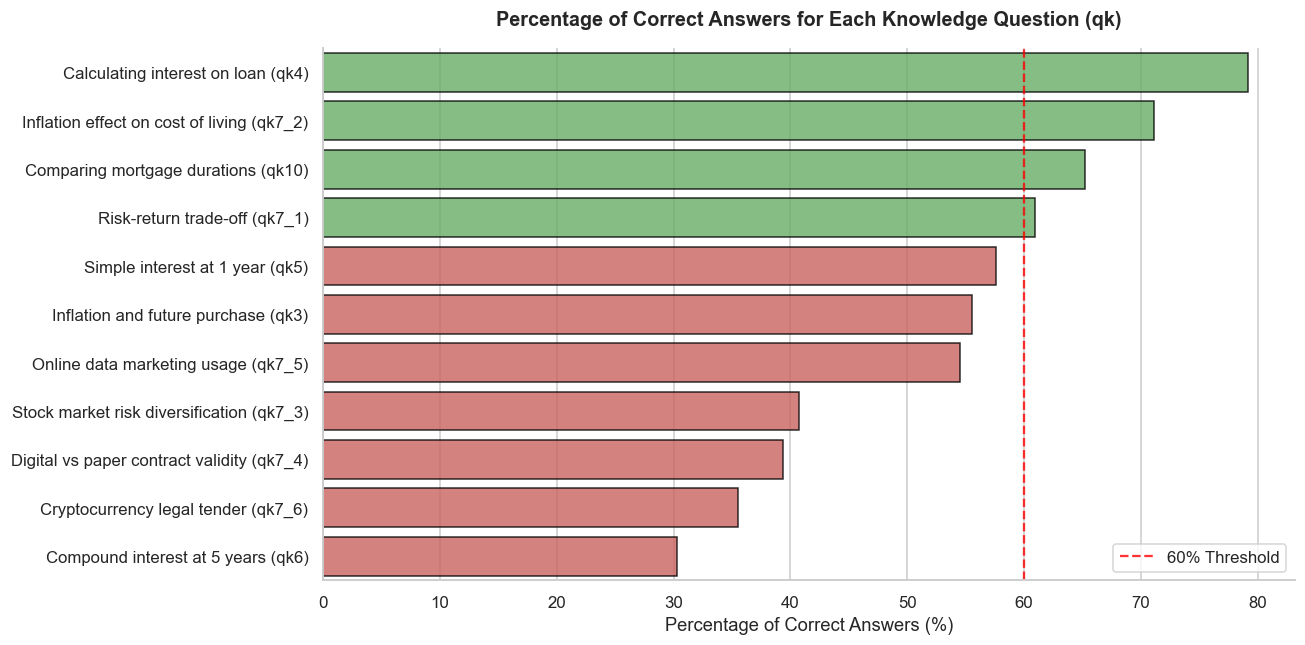

In [40]:
# Correct Answers Rate on the 11 Financial Knowledge Questions
risposte_corrette = {
    'qk3': 3, 'qk4': 0, 'qk5': 102, 'qk6': 1,
    'qk7_1': 1, 'qk7_2': 1, 'qk7_3': 1, 'qk7_4': 0, 'qk7_5': 1, 'qk7_6': 0,
    'qk10': 1
}

correct_scores = {}
for q, correct in risposte_corrette.items():
    correct_scores[q] = (df[q] == correct).mean() * 100

qk_descriptions = {
    'qk3': 'Inflation and future purchase (qk3)',
    'qk4': 'Calculating interest on loan (qk4)',
    'qk5': 'Simple interest at 1 year (qk5)',
    'qk6': 'Compound interest at 5 years (qk6)',
    'qk7_1': 'Risk-return trade-off (qk7_1)',
    'qk7_2': 'Inflation effect on cost of living (qk7_2)',
    'qk7_3': 'Stock market risk diversification (qk7_3)',
    'qk7_4': 'Digital vs paper contract validity (qk7_4)',
    'qk7_5': 'Online data marketing usage (qk7_5)',
    'qk7_6': 'Cryptocurrency legal tender (qk7_6)',
    'qk10': 'Comparing mortgage durations (qk10)'
}

qk_df = pd.DataFrame(list(correct_scores.items()), columns=['Variable', 'Correct'])
qk_df['Question'] = qk_df['Variable'].map(qk_descriptions)
qk_df = qk_df.sort_values(by='Correct', ascending=False)

colors = ['#5cb85c' if x >= 60 else '#d9534f' for x in qk_df['Correct']]

plt.figure(figsize=(12, 6))
sns.barplot(data=qk_df, x='Correct', y='Question', palette=colors, edgecolor="black", alpha=0.8)

plt.axvline(x=60, color='red', linestyle='--', alpha=0.8, label='60% Threshold')

plt.title("Percentage of Correct Answers for Each Knowledge Question (qk)", fontsize=13)
plt.xlabel("Percentage of Correct Answers (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Behavioral Attitudes and ESG (`qs`)

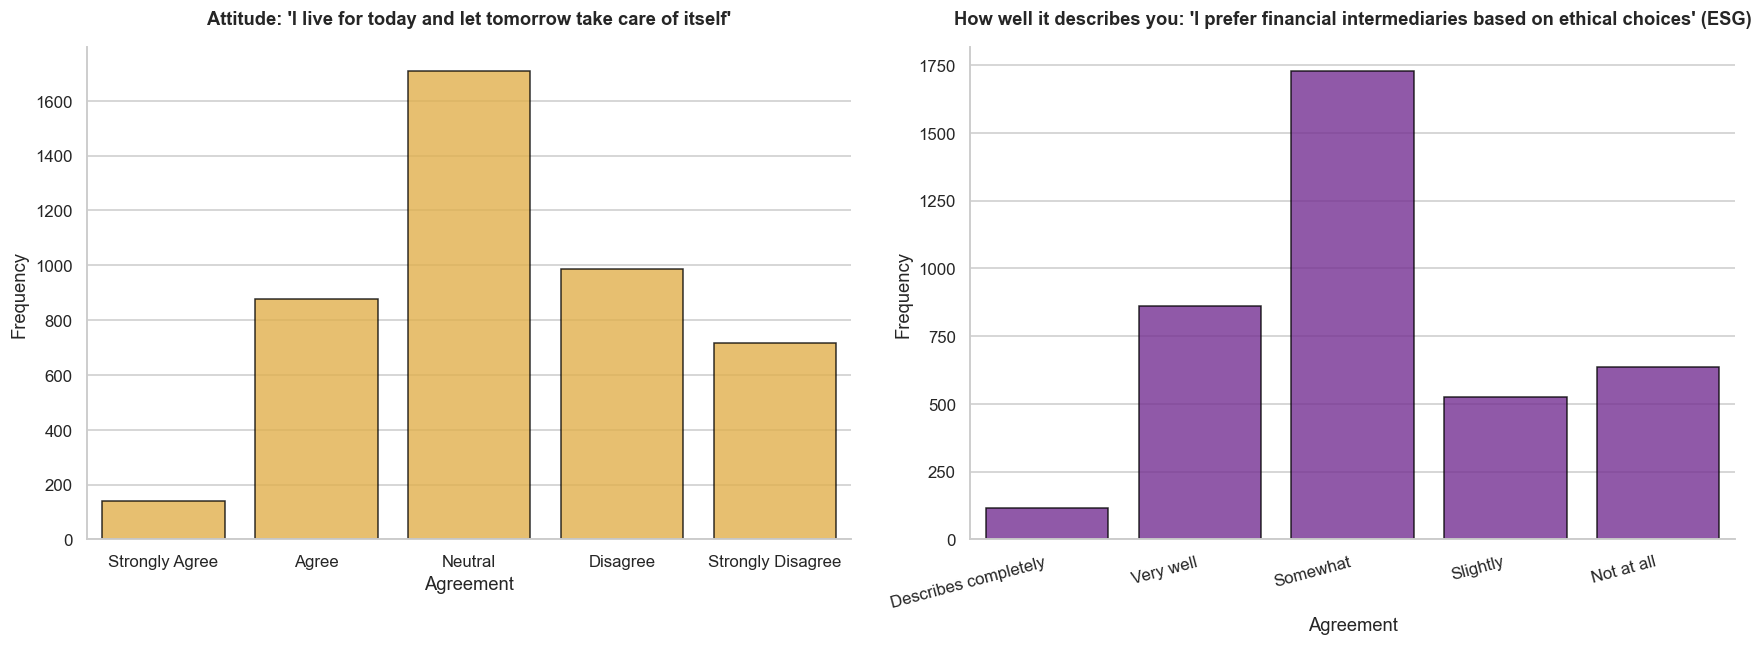

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Living for today and not thinking about tomorrow (qs3_11)
# Agreement mapping 1-5
attitude_data = df_clean['qs3_11'].dropna()
attitude_labels = {
    1: 'Strongly Agree',
    2: 'Agree',
    3: 'Neutral',
    4: 'Disagree',
    5: 'Strongly Disagree'
}
sns.countplot(x=attitude_data.map(attitude_labels), order=attitude_labels.values(), color="#FAB733", ax=axes[0], edgecolor="black", alpha=0.8)
axes[0].set_title("Attitude: 'I live for today and let tomorrow take care of itself'")
axes[0].set_xlabel("Agreement")
axes[0].set_ylabel("Frequency")

# 2. Preferences for ethical and ESG intermediaries (qs3_2)
esg_data = df_clean['qs3_2'].dropna()
esg_labels = {
    1: 'Describes completely',
    2: 'Very well',
    3: 'Somewhat',
    4: 'Slightly',
    5: 'Not at all'
}
sns.countplot(x=esg_data.map(esg_labels), order=esg_labels.values(), color="#7A1FA2", ax=axes[1], edgecolor="black", alpha=0.8)
axes[1].set_title("How well it describes you: 'I prefer financial intermediaries based on ethical choices' (ESG)")
axes[1].set_xlabel("Agreement")
axes[1].set_ylabel("Frequency")
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()